## 1.Выбор набора данных
Выберем набор данных из второй лабораторной

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline 
sns.set(style="ticks")
seed=123
np.random.seed(seed)

In [2]:
data = pd.read_csv('data/oasis_cross-sectional.csv', sep=",")
data.describe()

,Age,Educ,SES,MMSE,CDR,eTIV,nWBV,ASF,Delay
count,436.000000,235.000000,216.000000,235.00000,235.000000,436.000000,436.000000,436.000000,20.00000
mean,51.357798,3.178723,2.490741,27.06383,0.285106,1481.919725,0.791670,1.198894,20.55000
std,25.269862,1.311510,1.120593,3.69687,0.383405,158.740866,0.059937,0.128682,23.86249
min,18.000000,1.000000,1.000000,14.00000,0.000000,1123.000000,0.644000,0.881000,1.00000
25%,23.000000,2.000000,2.000000,26.00000,0.000000,1367.750000,0.742750,1.111750,2.75000
50%,54.000000,3.000000,2.000000,29.00000,0.000000,1475.500000,0.809000,1.190000,11.00000
75%,74.000000,4.000000,3.000000,30.00000,0.500000,1579.250000,0.842000,1.284250,30.75000
max,96.000000,5.000000,5.000000,30.00000,2.000000,1992.000000,0.893000,1.563000,89.00000


## 2. Удаление или заполнение пропусков и кодирование категориальных признаков.

In [3]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

In [4]:
# Удаляем неинформативные колонки и колонку с пустыми значениями
data = data.drop(columns=['ID', 'Delay', 'Hand'])

# Заполняем пропуски (используем медиану для числовых данных)
cols_to_impute = ['Educ', 'SES', 'MMSE', 'CDR']
imputer = SimpleImputer(strategy='median')
data[cols_to_impute] = imputer.fit_transform(data[cols_to_impute])

# Кодирование категориального признака пола
le = LabelEncoder()
data['M/F'] = le.fit_transform(data['M/F'])

In [5]:
# Формируем целевой признак (y) и матрицу признаков (X)
# Если CDR > 0, значит деменция есть (класс 1), иначе - здоров (класс 0)
y = (data['CDR'] > 0).astype(int)
X = data.drop(columns=['CDR'])

# Масштабирование признаков
scaler = MinMaxScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

display(X_scaled.head(3))

,M/F,Age,Educ,SES,MMSE,eTIV,nWBV,ASF
0,0.0,0.717949,0.25,0.5,0.9375,0.254315,0.397590,0.623167
1,0.0,0.474359,0.75,0.0,0.9375,0.027618,0.666667,0.953079
2,0.0,0.705128,0.75,0.5,0.8125,0.380898,0.257028,0.478006


## 3. С использованием метода train_test_split разделите выборку на обучающую и тестовую.

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=seed, stratify=y
)

print(f"Обучающая выборка: {X_train.shape[0]} строк")
print(f"Тестовая выборка: {X_test.shape[0]} строк")

Обучающая выборка: 305 строк
Тестовая выборка: 131 строк


## 4. Обучение моделей

### 1. Логистическая регрессия

In [8]:
from sklearn.linear_model import LogisticRegression

In [9]:
lr_model = LogisticRegression(random_state=seed)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

### 2. Метод опорных векторов

In [10]:
from sklearn.svm import SVC

In [30]:
svm_model = SVC(kernel='linear', random_state=seed)
svm_model.fit(X_train, y_train)
svm_pred = svm_model.predict(X_test)

svm_model1 = SVC(kernel='rbf', random_state=seed)
svm_model1.fit(X_train, y_train)
svm_pred1 = svm_model1.predict(X_test)

svm_model2 = SVC(kernel='poly', random_state=seed)
svm_model2.fit(X_train, y_train)
svm_pred2 = svm_model2.predict(X_test)

### 3. Дерево решений

In [12]:
from sklearn.tree import DecisionTreeClassifier, export_text

In [13]:
dt_model = DecisionTreeClassifier(max_depth=4, random_state=seed)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

## 5. Оценка качества моделей

In [14]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

In [15]:
def evaluate_model(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='weighted')
    print(f"Модель: {name}")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  F1-score : {f1:.4f}\n")

In [31]:
evaluate_model("Логистическая регрессия", y_test, lr_pred)
evaluate_model("Метод опорных векторов", y_test, svm_pred)
evaluate_model("Метод опорных векторов (rbf)", y_test, svm_pred1)
evaluate_model("Метод опорных векторов (poly)", y_test, svm_pred2)
evaluate_model("Дерево решений", y_test, dt_pred)

Модель: Логистическая регрессия
  Accuracy : 0.9008
  F1-score : 0.8941

Модель: Метод опорных векторов
  Accuracy : 0.9008
  F1-score : 0.8941

Модель: Метод опорных векторов (rbf)
  Accuracy : 0.8779
  F1-score : 0.8660

Модель: Метод опорных векторов (poly)
  Accuracy : 0.9237
  F1-score : 0.9237

Модель: Дерево решений
  Accuracy : 0.9313
  F1-score : 0.9290



## 6. График важности признаков

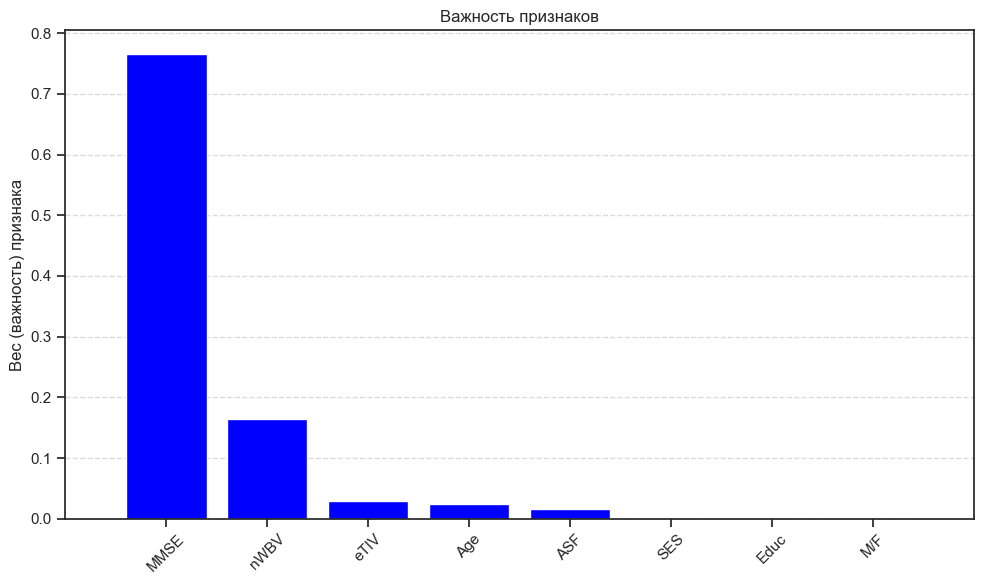

In [17]:
# Получаем важность признаков
importances = dt_model.feature_importances_
feature_names = X.columns

# Сортируем признаки по убыванию их важности
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Важность признаков")
plt.bar(range(X.shape[1]), importances[indices], color="blue", align="center")
plt.xticks(range(X.shape[1]), feature_names[indices], rotation=45)
plt.xlim([-1, X.shape[1]])
plt.ylabel("Вес (важность) признака")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 7. Вывод правил дерева решений

In [18]:
tree_rules = export_text(dt_model, feature_names=list(feature_names))
print("Правила принятия решений")
print(tree_rules)

Правила принятия решений
|--- MMSE <= 0.84
|   |--- nWBV <= 0.43
|   |   |--- Age <= 0.86
|   |   |   |--- class: 1
|   |   |--- Age >  0.86
|   |   |   |--- nWBV <= 0.38
|   |   |   |   |--- class: 1
|   |   |   |--- nWBV >  0.38
|   |   |   |   |--- class: 0
|   |--- nWBV >  0.43
|   |   |--- MMSE <= 0.69
|   |   |   |--- class: 1
|   |   |--- MMSE >  0.69
|   |   |   |--- ASF <= 0.66
|   |   |   |   |--- class: 0
|   |   |   |--- ASF >  0.66
|   |   |   |   |--- class: 1
|--- MMSE >  0.84
|   |--- nWBV <= 0.57
|   |   |--- eTIV <= 0.82
|   |   |   |--- Age <= 0.87
|   |   |   |   |--- class: 0
|   |   |   |--- Age >  0.87
|   |   |   |   |--- class: 0
|   |   |--- eTIV >  0.82
|   |   |   |--- class: 1
|   |--- nWBV >  0.57
|   |   |--- class: 0



In [19]:
#pip install pydotplus

In [20]:
#pip install graphviz

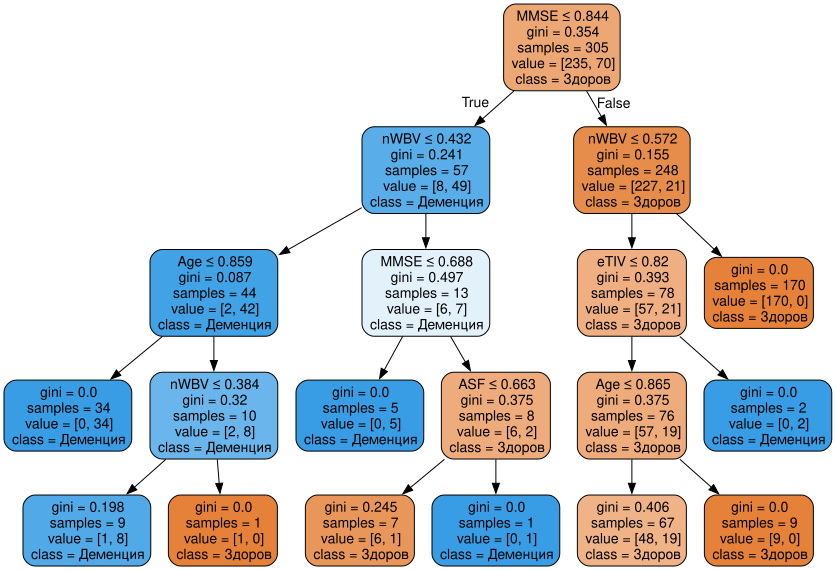

In [21]:
import graphviz
from sklearn.tree import export_graphviz

dot_data = export_graphviz(
    dt_model, 
    out_file=None, 
    feature_names=feature_names,
    class_names=['Здоров', 'Деменция'],
    filled=True, 
    rounded=True, 
    special_characters=True
)

graph = graphviz.Source(dot_data)
graph